Name: Dano Alvin John S <br>Course and Section: CPE311-CPE22S3 <br>Date: 4/7/26 <br>Instructor: Engr.
Neal Barton James Matira

 Intended Learning Outcome

    Perform descriptive and correlation analysis to to analyze the dataset.
    Interpret the results of descriptive and correlation analysis

Resources

    Personal Computer
    Jupyter Notebook
    Internet Connection

Instruction

1. Gather a dataset regarding your identified problem for the ASEAN Data Science Explorer. You may look at previous ADSE Competitions for Problem References. Make sure that the dataset includes multiple variables.
2. Load the dataset into pandas dataframe.
3. Prepare the data by applying appropriate data preprocessing techniques.
4. Analyze the data using descriptive analysis.
4. Perform correlation analysis.
5. Interpret the results based on the descriptive and correlation analysis.
6. Submit the PDF file and comment an accessible link.

The Association of Southeast Asian Nations (ASEAN) is one of the world’s most diverse economic blocs, ranging from high-income financial hubs to emerging agrarian economies. This diversity creates a unique "multi-speed" inflation landscape.

[OK] DATA LOADED
[OK] DATA CLEANED


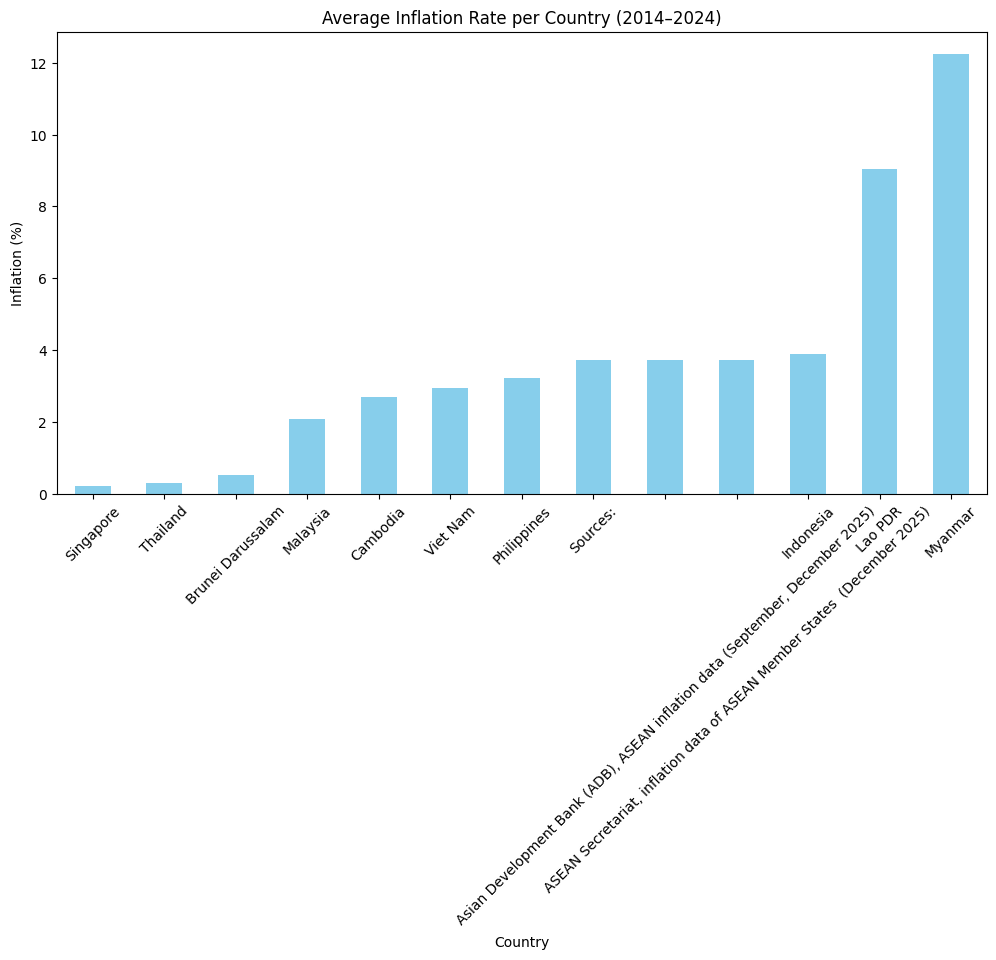

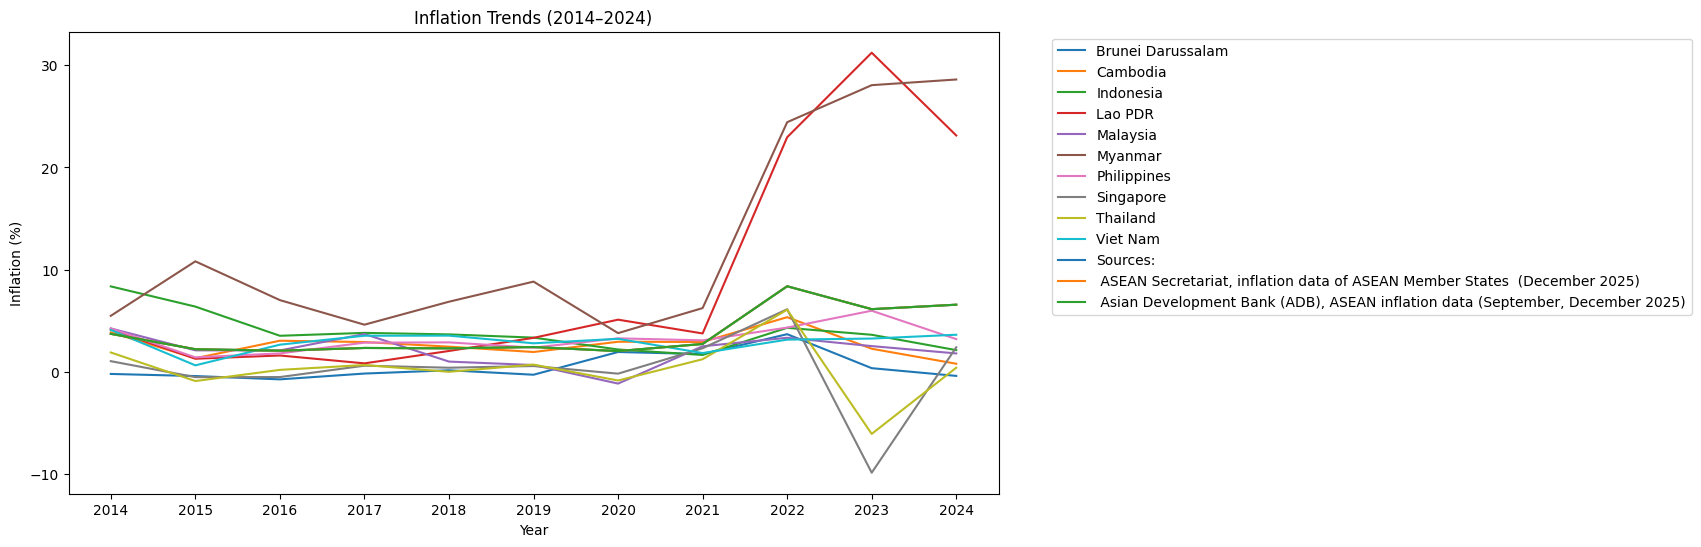

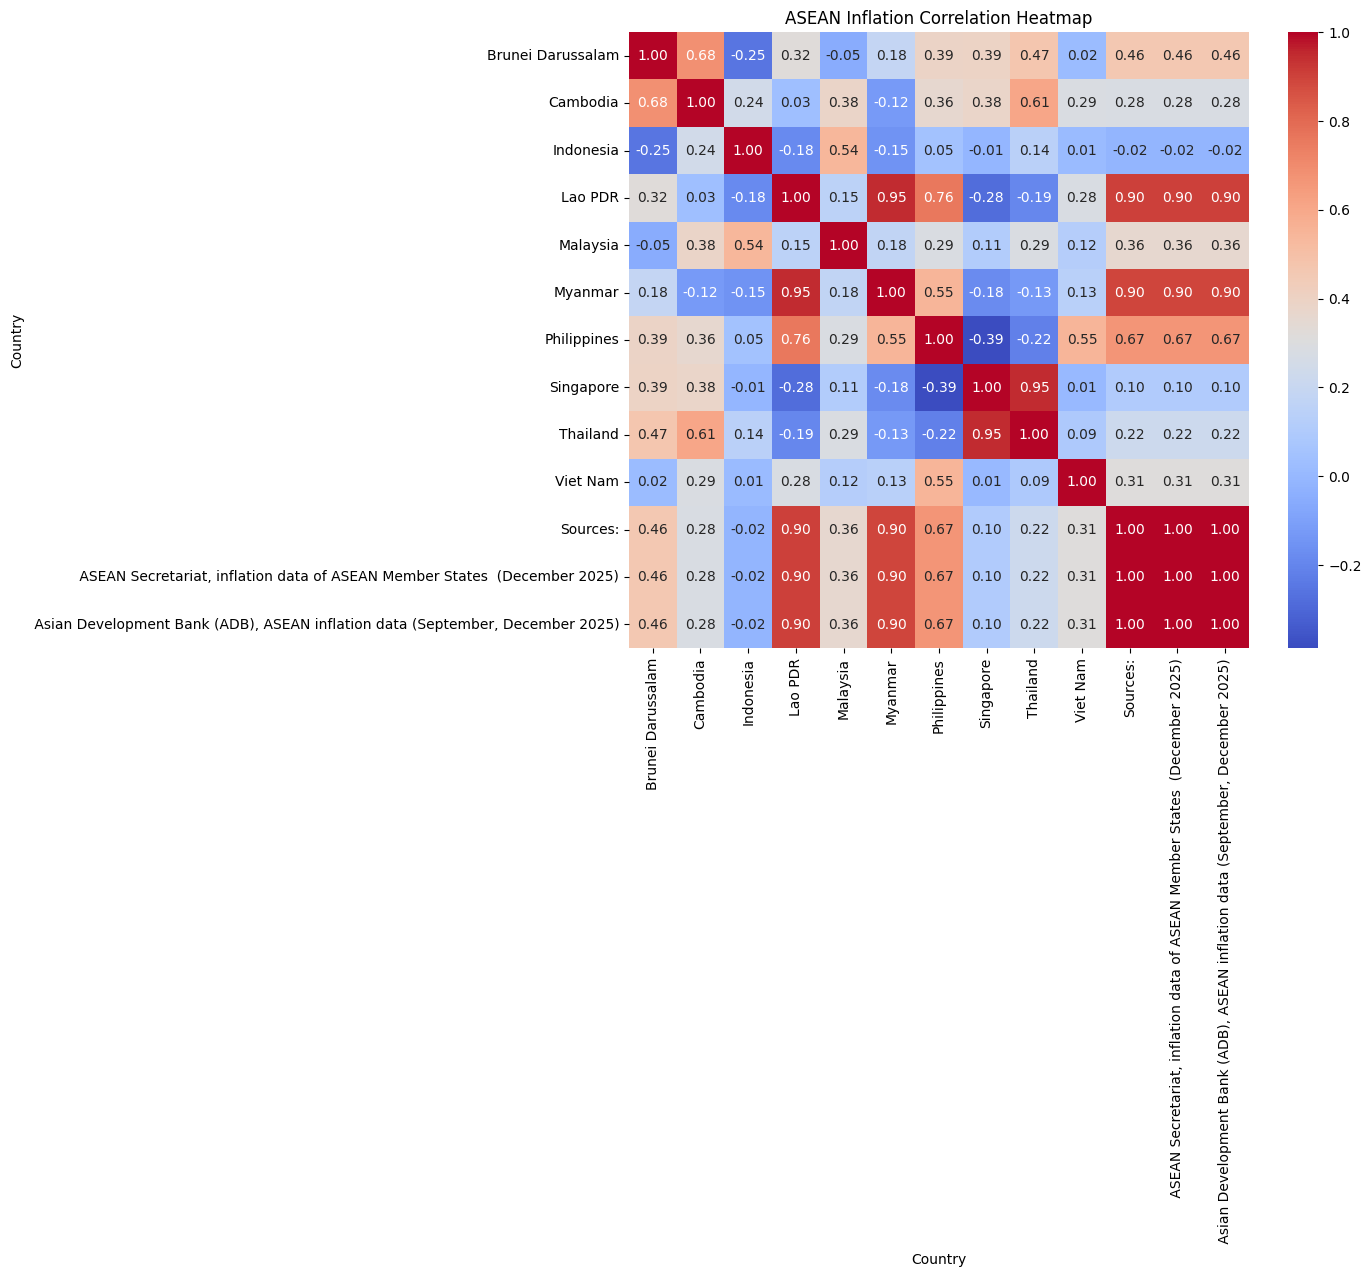


INTERPRETATION 

Top 5 Strongest Positive Correlations:
 ASEAN Secretariat, inflation data of ASEAN Member States  (December 2025) &  Asian Development Bank (ADB), ASEAN inflation data (September, December 2025): 1.00
Sources: &  Asian Development Bank (ADB), ASEAN inflation data (September, December 2025): 1.00
Sources: &  ASEAN Secretariat, inflation data of ASEAN Member States  (December 2025): 1.00
Lao PDR & Myanmar: 0.95
Singapore & Thailand: 0.95

Top 5 Weakest Correlations (Closest to 0):
Singapore & Viet Nam: 0.01
Indonesia & Viet Nam: 0.01
Indonesia & Singapore: -0.01
Indonesia & Sources:: -0.02
Indonesia &  Asian Development Bank (ADB), ASEAN inflation data (September, December 2025): -0.02


In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD DATA (FIXED HEADER ISSUE)

file_path = "/content/Inflation rate, year-on-year change of the consumer price index, average of period (in percent).xlsx"
df = pd.read_excel(file_path, skiprows=3)
df.columns = ["Country", "Base year", "2014", "2015", "2016", "2017",
              "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
print("[OK] DATA LOADED")

# 3. DATA CLEANING / PREPROCESSING
df = df[df["Country"].notna()]
df = df[df["Country"] != "ASEAN"]
df.drop(columns=["Base year"], inplace=True)
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.fillna(df.mean(numeric_only=True), inplace=True)
df.set_index("Country", inplace=True)

print("[OK] DATA CLEANED")

# 4. DESCRIPTIVE ANALYSIS
mean_per_country = df.mean(axis=1)
std_per_country = df.std(axis=1)

# --- Bar chart: Average inflation ---
plt.figure(figsize=(12,6))
mean_per_country.sort_values().plot(kind='bar', color='skyblue')
plt.title("Average Inflation Rate per Country (2014–2024)")
plt.ylabel("Inflation (%)")
plt.xticks(rotation=45)
plt.show()

# --- Line chart: Inflation trends ---
plt.figure(figsize=(12,6))
for country in df.index:
    plt.plot(df.columns, df.loc[country], label=country)

plt.title("Inflation Trends (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# 5. CORRELATION ANALYSIS

corr_matrix = df.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("ASEAN Inflation Correlation Heatmap")
plt.show()

# 6. AUTOMATED INTERPRETATION
print("\nINTERPRETATION ")
# Highest / lowest inflation
highest_avg = mean_per_country.idxmax()
lowest_avg = mean_per_country.idxmin()

# Most / least stable
most_volatile = std_per_country.idxmax()
least_volatile = std_per_country.idxmin()


# GET UNIQUE CORRELATION PAIRS
corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        country1 = corr_matrix.columns[i]
        country2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        corr_pairs.append((country1, country2, corr_value))

# Convert to DataFrame for easy sorting
corr_df = pd.DataFrame(corr_pairs, columns=["Country1", "Country2", "Correlation"])


top_strong = corr_df.sort_values(by="Correlation", ascending=False).head(5)

print("\nTop 5 Strongest Positive Correlations:")
for _, row in top_strong.iterrows():
    print(f"{row['Country1']} & {row['Country2']}: {row['Correlation']:.2f}")

top_weak = corr_df.reindex(corr_df["Correlation"].abs().sort_values().index).head(5)

print("\nTop 5 Weakest Correlations (Closest to 0):")
for _, row in top_weak.iterrows():
    print(f"{row['Country1']} & {row['Country2']}: {row['Correlation']:.2f}")

#Final Summary
Basically, Inflation across ASEAN countries shows moderate levels overall, typically between 2%–5%. Moreover, Some countries experience extreme inflation, indicating economic instability. Coupled with, Countries with high standard deviation have unstable inflation trends. Additionally, a strong correlations suggest shared economic influences such as global oil prices or supply chain shocks.However, a weak correlations indicate differences in economic structure, policy, or external exposure. And lastly Regional inflation spikes are visible during global crises (e.g., post-pandemic period).